In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
url = "https://raw.githubusercontent.com/Nimisolanki/COVID-19-Unemployment-Analysis/refs/heads/main/Unemployment%20in%20India.csv"

df = pd.read_csv(url)

df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [ ]:
print("Shape of Dataset:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
df.info()

Shape of Dataset: (768, 7)

Column Names:
Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtype

In [ ]:
df.columns = df.columns.str.strip()

print(df.columns)

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')


In [ ]:
print(df.isnull().sum())

Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64


In [ ]:
df.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


In [ ]:
df["Date"] = pd.to_datetime(df["Date"])

print(df["Date"].dtype)

datetime64[ns]


/tmp/ipykernel_1376/1363175392.py:3: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Date"] = pd.to_datetime(df["Date"])


In [ ]:
print("Total Regions:", df["Region"].nunique())

print(df["Region"].unique())

Total Regions: 28
['Andhra Pradesh' 'Assam' 'Bihar' 'Chhattisgarh' 'Delhi' 'Goa' 'Gujarat'
 'Haryana' 'Himachal Pradesh' 'Jammu & Kashmir' 'Jharkhand' 'Karnataka'
 'Kerala' 'Madhya Pradesh' 'Maharashtra' 'Meghalaya' 'Odisha' 'Puducherry'
 'Punjab' 'Rajasthan' 'Sikkim' 'Tamil Nadu' 'Telangana' 'Tripura'
 'Uttar Pradesh' 'Uttarakhand' 'West Bengal' nan 'Chandigarh']


In [ ]:
# Count Urban and Rural data

print(df["Area"].value_counts())

Area
Urban    381
Rural    359
Name: count, dtype: int64


In [ ]:
# Average unemployment rate by region

region_unemployment = (
    df.groupby("Region")["Estimated Unemployment Rate (%)"]
      .mean()
      .sort_values(ascending=False)
)

print(region_unemployment)

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Punjab              12.031071
Puducherry          10.215000
Kerala              10.123929
Tamil Nadu           9.284286
Goa                  9.274167
Chhattisgarh         9.240357
West Bengal          8.124643
Telangana            7.737857
Maharashtra          7.557500
Andhra Pradesh       7.477143
Madhya Pradesh       7.406429
Sikkim               7.249412
Karnataka            6.676071
Gujarat              6.663929
Uttarakhand          6.582963
Assam                6.428077
Odisha               5.657857
Meghalaya            4.798889
Name: Estimated Unemployment Rate (%), dtype: float64


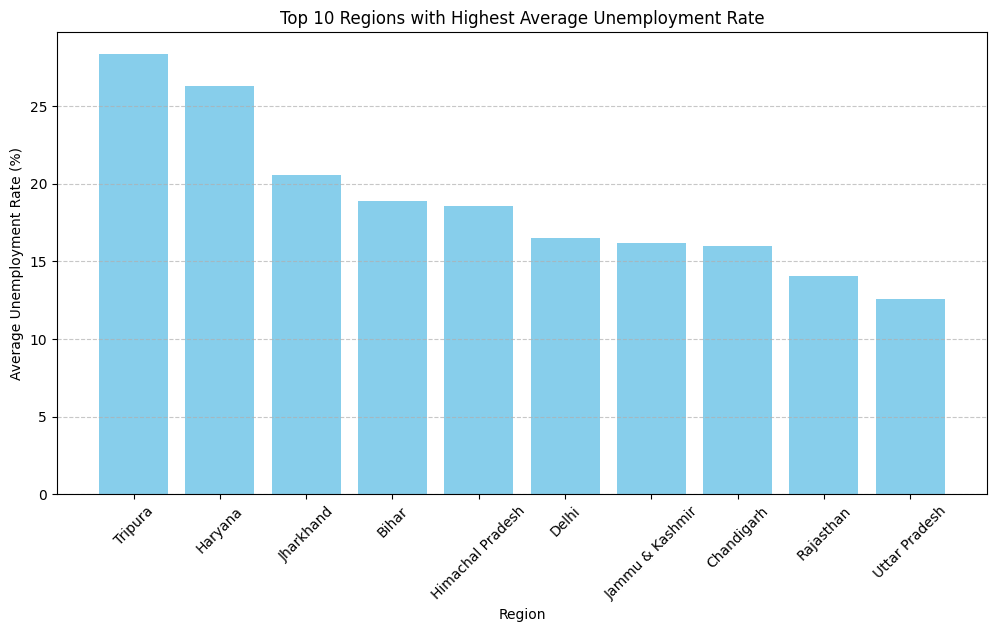

In [ ]:
# Top 10 regions with highest average unemployment rate

top10 = (
    df.groupby("Region")["Estimated Unemployment Rate (%)"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

plt.bar(top10.index, top10.values, color='skyblue')

plt.title("Top 10 Regions with Highest Average Unemployment Rate")
plt.xlabel("Region")
plt.ylabel("Average Unemployment Rate (%)")

plt.xticks(rotation=45)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

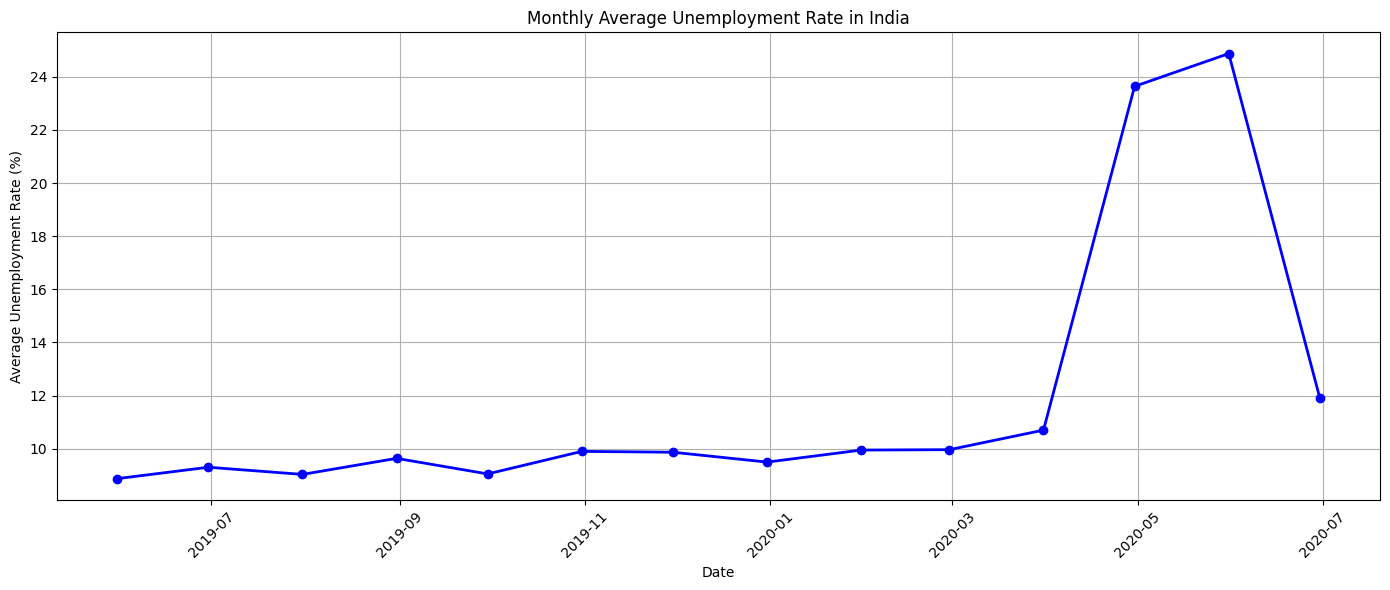

In [ ]:
# Calculate monthly average unemployment rate

monthly_unemployment = (
    df.groupby("Date")["Estimated Unemployment Rate (%)"]
      .mean()
)


plt.figure(figsize=(14,6))

plt.plot(monthly_unemployment.index,
         monthly_unemployment.values,
         marker='o',
         linewidth=2,
         color='blue')

plt.title("Monthly Average Unemployment Rate in India")
plt.xlabel("Date")
plt.ylabel("Average Unemployment Rate (%)")

plt.grid(True)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [ ]:
### Observation

# The unemployment rate increased significantly during the COVID-19 lockdown period, especially around April and May 2020. This increase was mainly due to business closures, movement restrictions, and reduced economic activities. As restrictions were gradually lifted, the unemployment rate started to decline, indicating a gradual economic recovery.

In [ ]:
# Calculate average unemployment rate by Area (Urban/Rural)

area_unemployment = (
    df.groupby("Area")["Estimated Unemployment Rate (%)"]
      .mean()
)

print(area_unemployment)

Area
Rural    10.324791
Urban    13.166614
Name: Estimated Unemployment Rate (%), dtype: float64


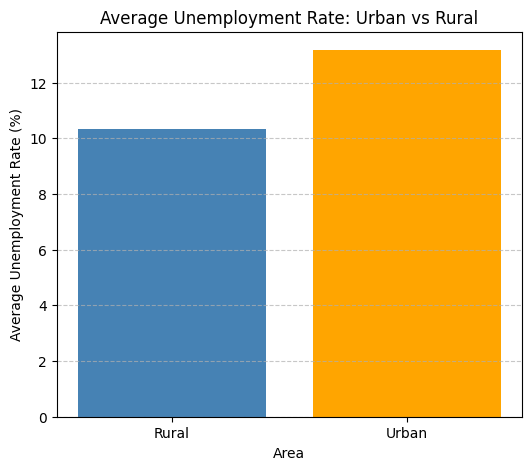

In [ ]:
plt.figure(figsize=(6,5))

plt.bar(
    area_unemployment.index,
    area_unemployment.values,
    color=["steelblue", "orange"]
)

plt.title("Average Unemployment Rate: Urban vs Rural")
plt.xlabel("Area")
plt.ylabel("Average Unemployment Rate (%)")

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [ ]:
### Observation

#The comparison between Urban and Rural areas shows a noticeable difference in unemployment rates. Urban areas generally experienced higher unemployment during the COVID-19 period because many industries, businesses, and service sectors were temporarily closed. Rural areas were also affected, but the impact was comparatively lower in most regions.

In [ ]:
# Top 10 regions with highest average employment

top_employment = (
    df.groupby("Region")["Estimated Employed"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

print(top_employment)

Region
Uttar Pradesh     2.809483e+07
Maharashtra       1.999020e+07
West Bengal       1.719854e+07
Bihar             1.236619e+07
Tamil Nadu        1.226955e+07
Gujarat           1.140201e+07
Madhya Pradesh    1.111548e+07
Karnataka         1.066712e+07
Rajasthan         1.004106e+07
Andhra Pradesh    8.154093e+06
Name: Estimated Employed, dtype: float64


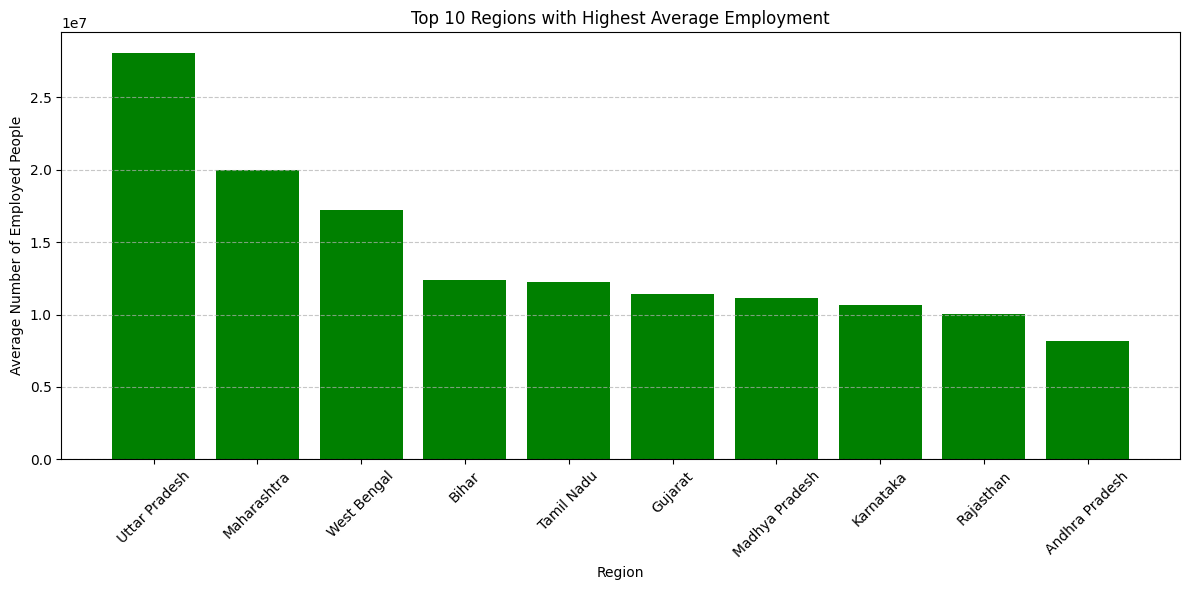

In [ ]:
plt.figure(figsize=(12,6))

plt.bar(
    top_employment.index,
    top_employment.values,
    color="green"
)

plt.title("Top 10 Regions with Highest Average Employment")
plt.xlabel("Region")
plt.ylabel("Average Number of Employed People")

plt.xticks(rotation=45)

plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()

plt.show()

In [ ]:
### Observation

#The graph shows the regions with the highest average number of employed people. Regions with larger populations and stronger industrial or agricultural sectors generally have higher employment figures. However, a high employment count does not necessarily indicate a low unemployment rate, as unemployment depends on the size of the labor force as well.

In [ ]:
# Conclusion

#This project analyzed the unemployment rate in India using Python and data analysis techniques. The dataset was cleaned by removing unnecessary spaces from column names and converting the date column into datetime format. Exploratory Data Analysis (EDA) was performed to understand the structure, missing values, and statistical summary of the dataset.

#Several visualizations were created to analyze unemployment trends across different regions, compare Urban and Rural unemployment rates, and study employment patterns. The analysis showed significant differences in unemployment rates among various regions of India.

#The monthly trend analysis highlighted the impact of the COVID-19 pandemic. During the lockdown period, unemployment rates increased sharply due to business closures, reduced industrial activities, and movement restrictions. As economic activities gradually resumed, unemployment rates started to decline.

#The Urban vs Rural comparison indicated that urban areas were more affected by unemployment because industries, offices, and service sectors experienced greater disruption during the pandemic.

## Key Insights

#- COVID-19 had a significant impact on unemployment across India.
#- Urban regions experienced higher unemployment than rural regions.
#- Unemployment rates varied considerably across different states and regions.
#- Employment levels were generally higher in densely populated and economically developed regions.

## Policy Recommendations

#- Increase employment opportunities through skill development and vocational training programs.
#- Support small and medium-sized businesses during economic crises.
#- Promote rural employment schemes and infrastructure development.
#- Strengthen social security programs for unemployed workers.
#- Encourage digital employment and remote work opportunities.

#Overall, this project demonstrated how Python can be used for data cleaning, visualization, and analysis to understand unemployment trends and generate meaningful insights for economic and social policy planning.